In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    Activation,
    GlobalAveragePooling2D
)

from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Carregar CIFAR-100

(x_train, y_train), (x_test, y_test) = cifar100.load_data()

print("X_train:", x_train.shape)
print("y_train:", y_train.shape)

print("X_test :", x_test.shape)
print("y_test :", y_test.shape)

print("\nNúmero de classes:", len(np.unique(y_train)))

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 3663s 22us/step
X_train: (50000, 32, 32, 3)
y_train: (50000, 1)
X_test : (10000, 32, 32, 3)
y_test : (10000, 1)

Número de classes: 100


In [ ]:
import psutil
import platform
from tensorflow.python.client import device_lib

print("=== Sistema Operacional ===")
print(f"SO: {platform.system()} {platform.release()}")

print("\n=== CPU ===")
!lscpu | grep 'Model name'
print(f"Núcleos físicos: {psutil.cpu_count(logical=False)}")
print(f"Total de núcleos (threads): {psutil.cpu_count(logical=True)}")

print("\n=== Memória RAM ===")
mem = psutil.virtual_memory()
print(f"Total: {mem.total / (1024**3):.2f} GB")
print(f"Disponível: {mem.available / (1024**3):.2f} GB")

print("\n=== GPU ===")
!nvidia-smi --query-gpu=gpu_name,memory.total --format=csv,noheader

=== Sistema Operacional ===
SO: Linux 6.6.122+

=== CPU ===
Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz
Núcleos físicos: 1
Total de núcleos (threads): 2

=== Memória RAM ===
Total: 12.67 GB
Disponível: 10.89 GB

=== GPU ===
Tesla T4, 15360 MiB


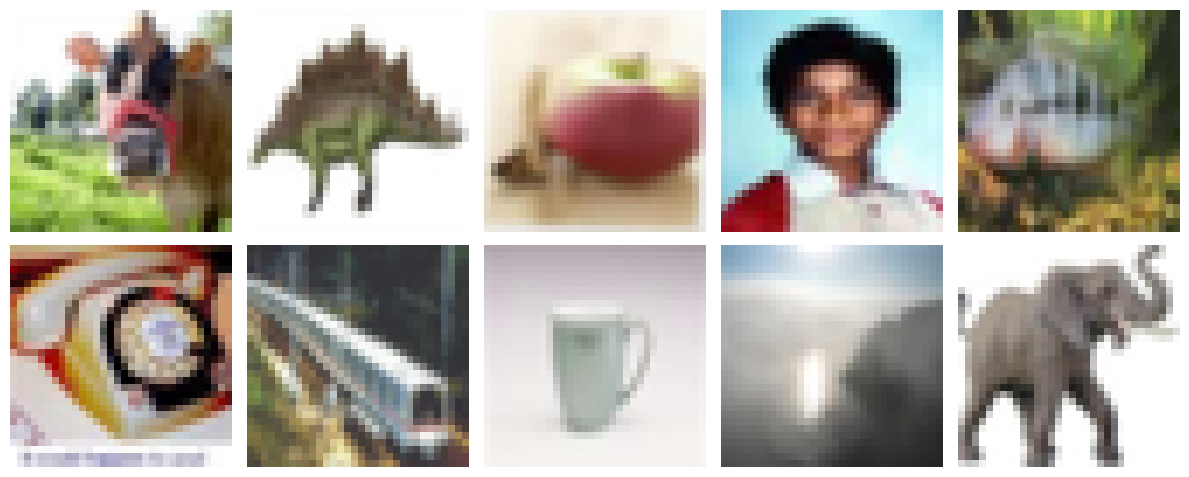

In [ ]:
from tensorflow.keras.utils import to_categorical

# Normalização dos pixels
X_train = x_train.astype("float32") / 255.0
X_test = x_test.astype("float32") / 255.0

# One-Hot Encoding para 100 classes
y_train_cat = to_categorical(y_train, 100)
y_test_cat = to_categorical(y_test, 100)

# Separação de validação (10%)
X_val = X_train[:5000]
y_val = y_train_cat[:5000]

X_train_f = X_train[5000:]
y_train_f = y_train_cat[5000:]

print("Treino:", X_train_f.shape, y_train_f.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test_cat.shape)

Treino: (45000, 32, 32, 3) (45000, 100)
Validação: (5000, 32, 32, 3) (5000, 100)
Teste: (10000, 32, 32, 3) (10000, 100)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train_f)

print("Data Augmentation configurado com sucesso!")

Data Augmentation configurado com sucesso!


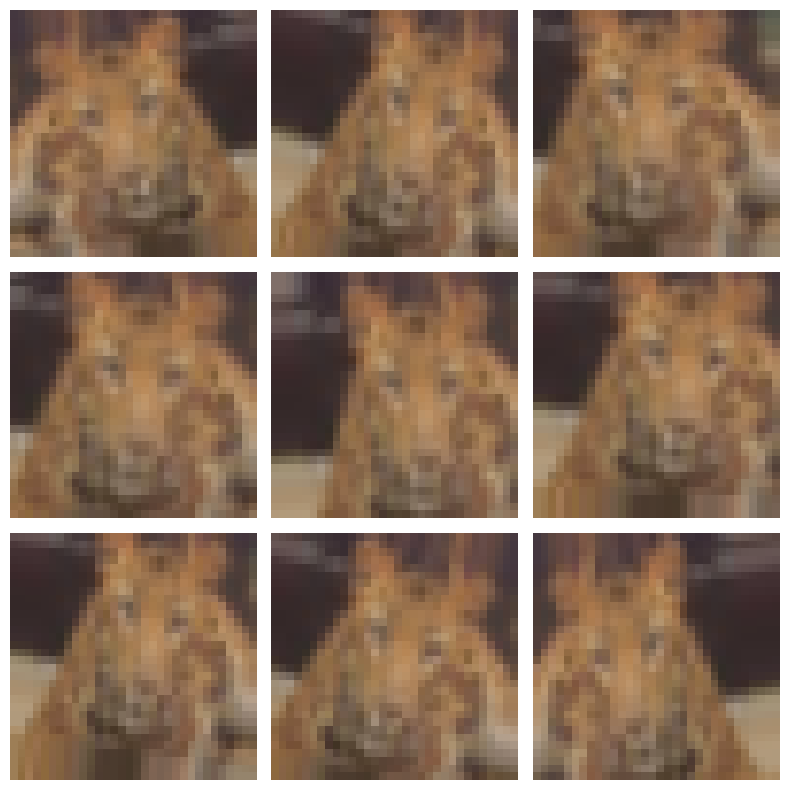

In [ ]:
plt.figure(figsize=(8,8))

gerador = datagen.flow(X_train_f[:1], batch_size=1)

for i in range(9):
    plt.subplot(3,3,i+1)

    imagem = next(gerador)[0]

    plt.imshow(imagem)
    plt.axis('off')

plt.tight_layout()
plt.savefig("augmentation_exemplos.png", dpi=150)
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    Activation,
    GlobalAveragePooling2D
)

model = Sequential()

# ===== BLOCO 1 =====
# Extrai características básicas (bordas, cores, texturas)
model.add(Conv2D(64, (3,3), padding='same',
                 input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(64, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# ===== BLOCO 2 =====
# Aprende padrões mais complexos
model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# ===== BLOCO 3 =====
# Aprende partes de objetos
model.add(Conv2D(256, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(256, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.35))

# ===== BLOCO 4 =====
# Aprende representações de alto nível
model.add(Conv2D(512, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Conv2D(512, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.35))

# ===== CLASSIFICADOR =====
# Reduz parâmetros e ajuda contra overfitting
model.add(GlobalAveragePooling2D())

model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dropout(0.5))

# Saída obrigatória para CIFAR-100
model.add(Dense(100, activation='softmax'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 8, 8, 256)      │             

 Total params: 5,009,060 (19.11 MB)

 Trainable params: 5,004,196 (19.09 MB)

 Non-trainable params: 4,864 (19.00 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'melhor_modelo.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Modelo compilado e callbacks configurados.")

Modelo compilado e callbacks configurados.


In [ ]:
history_v2 = model.fit(
    datagen.flow(
        X_train_f,
        y_train_f,
        batch_size=64
    ),
    steps_per_epoch=len(X_train_f) // 64,
    validation_data=(X_val, y_val),
    epochs=150,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint_v2
    ],
    verbose=1
)

Epoch 1/150
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.0521 - loss: 4.4446
Epoch 1: val_accuracy improved from None to 0.11920, saving model to melhor_modelo.keras

Epoch 1: finished saving model to melhor_modelo.keras
703/703 ━━━━━━━━━━━━━━━━━━━━ 64s 66ms/step - accuracy: 0.0758 - loss: 4.1441 - val_accuracy: 0.1192 - val_loss: 3.7652 - learning_rate: 0.0010
Epoch 2/150
  1/703 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.0625 - loss: 3.9044

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.11920
703/703 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0625 - loss: 3.9044 - val_accuracy: 0.1110 - val_loss: 3.8047 - learning_rate: 0.0010
Epoch 3/150
702/703 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1443 - loss: 3.5752
Epoch 3: val_accuracy improved from 0.11920 to 0.15480, saving model to melhor_modelo.keras

Epoch 3: finished saving model to melhor_modelo.keras
703/703 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.1658 - loss: 3.4444 - val_accuracy: 0.1548 - val_loss: 3.7260 - learning_rate: 0.0010
Epoch 4/150
  1/703 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.1719 - loss: 3.5450
Epoch 4: val_accuracy did not improve from 0.15480
703/703 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1719 - loss: 3.5450 - val_accuracy: 0.1504 - val_loss: 3.8092 - learning_rate: 0.0010
Epoch 5/150
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2318 - loss: 3.0754
Epoch 5: val_accuracy improved from 0.15480 to 0.26880, savi

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_v2 = ModelCheckpoint(
    'melhor_modelo_v2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [ ]:
history_v2 = model.fit(
    datagen.flow(
        X_train_f,
        y_train_f,
        batch_size=64
    ),
    steps_per_epoch=len(X_train_f) // 64,
    validation_data=(X_val, y_val),
    epochs=150,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

Epoch 1/150
702/703 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.0461 - loss: 4.4812
Epoch 1: val_accuracy improved from None to 0.07800, saving model to melhor_modelo.keras

Epoch 1: finished saving model to melhor_modelo.keras
703/703 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - accuracy: 0.0681 - loss: 4.1773 - val_accuracy: 0.0780 - val_loss: 4.2302 - learning_rate: 0.0010
Epoch 2/150
  1/703 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.1094 - loss: 3.8779
Epoch 2: val_accuracy improved from 0.07800 to 0.08160, saving model to melhor_modelo.keras

Epoch 2: finished saving model to melhor_modelo.keras
703/703 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1094 - loss: 3.8779 - val_accuracy: 0.0816 - val_loss: 4.1519 - learning_rate: 0.0010
Epoch 3/150
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1335 - loss: 3.6460
Epoch 3: val_accuracy improved from 0.08160 to 0.13700, saving model to melhor_modelo.keras

Epoch 3: finished saving model to melhor_modelo.keras
703/703 ━━━━━

In [ ]:
import os

print(os.listdir())

['.config', 'augmentation_exemplos.png', 'melhor_modelo.keras', 'amostras_cifar100.png', 'sample_data']


In [ ]:
!ls

amostras_cifar100.png	   melhor_modelo.keras	 modelo_v3.keras
augmentation_exemplos.png  modelo_v2_6506.keras  sample_data


In [ ]:
from tensorflow.keras.models import load_model

modelo_campeao = load_model("melhor_modelo.keras")

print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


In [ ]:
from tensorflow.keras.models import load_model

modelo = load_model("melhor_modelo.keras")

loss, acc = modelo.evaluate(
    X_val,
    y_val,
    verbose=1
)

print("Val Accuracy:", acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6506 - loss: 1.3117
Val Accuracy: 0.650600016117096


In [ ]:
!cp melhor_modelo.keras modelo_v2_6506.keras

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_v3 = ModelCheckpoint(
    'modelo_v3.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [ ]:
history_v3 = model.fit(
    datagen.flow(
        X_train_f,
        y_train_f,
        batch_size=32
    ),
    steps_per_epoch=len(X_train_f) // 32,
    validation_data=(X_val, y_val),
    epochs=150,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint_v3
    ],
    verbose=1
)

Epoch 1/150
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0397 - loss: 4.5165
Epoch 1: val_accuracy improved from None to 0.10280, saving model to modelo_v3.keras

Epoch 1: finished saving model to modelo_v3.keras
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 67s 35ms/step - accuracy: 0.0581 - loss: 4.2376 - val_accuracy: 0.1028 - val_loss: 3.7566 - learning_rate: 0.0010
Epoch 2/150
   1/1406 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.1562 - loss: 3.8024
Epoch 2: val_accuracy improved from 0.10280 to 0.10360, saving model to modelo_v3.keras

Epoch 2: finished saving model to modelo_v3.keras
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 1s 860us/step - accuracy: 0.1562 - loss: 3.8024 - val_accuracy: 0.1036 - val_loss: 3.7471 - learning_rate: 0.0010
Epoch 3/150
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1159 - loss: 3.7212
Epoch 3: val_accuracy improved from 0.10360 to 0.13620, saving model to modelo_v3.keras

Epoch 3: finished saving model to modelo_v3.keras
1406/1406 ━━━━━━━━━━━━━━━

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint_v4 = ModelCheckpoint(
    'modelo_v4.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("V4 compilada.")

V4 compilada.


In [ ]:
history_v4 = model.fit(
    datagen.flow(
        X_train_f,
        y_train_f,
        batch_size=32
    ),
    steps_per_epoch=len(X_train_f) // 32,
    validation_data=(X_val, y_val),
    epochs=150,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint_v4
    ],
    verbose=1
)

Epoch 1/150
1405/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1048 - loss: 3.8455
Epoch 1: val_accuracy improved from None to 0.17920, saving model to modelo_v4.keras

Epoch 1: finished saving model to modelo_v4.keras
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.1255 - loss: 3.6928 - val_accuracy: 0.1792 - val_loss: 3.3423 - learning_rate: 5.0000e-04
Epoch 2/150
   1/1406 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.1875 - loss: 3.3290
Epoch 2: val_accuracy improved from 0.17920 to 0.18300, saving model to modelo_v4.keras

Epoch 2: finished saving model to modelo_v4.keras
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 1s 887us/step - accuracy: 0.1875 - loss: 3.3290 - val_accuracy: 0.1830 - val_loss: 3.3322 - learning_rate: 5.0000e-04
Epoch 3/150
1405/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1883 - loss: 3.3065
Epoch 3: val_accuracy improved from 0.18300 to 0.22540, saving model to modelo_v4.keras

Epoch 3: finished saving model to modelo_v4.keras
1406/1406 ━━━━━━━

In [37]:
!ls *.keras

melhor_modelo.keras  modelo_v2_6506.keras  modelo_v3.keras  modelo_v4.keras
